In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from networkx.drawing.nx_agraph import graphviz_layout
from scipy.interpolate import Rbf


In [ ]:
VERBOSE = True
TEST = "allcelltypes"
EVENT_TYPES = ["S_to_I", "I_to_S"]

PROJECT_PATH = r"G:\XJN_M2project"
OUTPUT_DIR = os.path.join(PROJECT_PATH, "correlation_analysis", TEST)

R_THRESHOLDs = np.arange(0.5, 0.95, step=0.05)
R_THRESHOLDs = [0.9]

TOP_N = 10
GRAPHVIZ_PROG = "twopi"
SHOW_VISUALIZATION = True
N_BOOT = 5000
RANDOM_STATE = 42

CELLTYPE_NAME_MAP = {
    1: "CamkII_TST",
    2: "PV",
    3: "SST",
    4: "VIP",
}
CELLTYPE_COLOR_MAP = {
    1: "#E5D4E8",
    2: "#1B7939",
    3: "#F2A529",
    4: "#B31529",
}
EVENT_CURVE_COLOR_MAP = {
    "I_to_S": "#C06000",
    "S_to_I": "#000080",
}


## Helpers

This notebook uses the already-built all-type correlation matrix and applies a direct **r-threshold** edge-selection rule:

- keep edge if `r > R_THRESHOLD`
- remove edge otherwise

The main workflow is edge-threshold analysis; the CaMKII node-weighted bootstrap CI section is appended as a supplemental robustness / uncertainty analysis on top of the currently filtered network.


In [3]:
def load_and_validate_data(file_path, test, verbose=True):
    if verbose:
        print(f"[load] reading correlation matrix from: {file_path}")

    data = pd.read_csv(file_path, header=0, index_col=0)
    if data.empty:
        raise ValueError("Input correlation matrix is empty.")

    celltype_info = None
    if "celltype" in data.columns:
        celltype_info = data["celltype"].reset_index(drop=True)
        data = data.drop(columns="celltype")
    else:
        print("[fallback] `celltype` column not found; downstream celltype-specific outputs will use NaN.")

    if data.shape[0] != data.shape[1]:
        raise ValueError(f"Correlation matrix must be square, got {data.shape}.")

    row_ids = pd.Index(data.index)
    col_ids = pd.Index(data.columns)
    if len(row_ids) != len(col_ids):
        raise ValueError("Row/column size mismatch.")

    row_ids_num = pd.to_numeric(row_ids, errors="coerce")
    col_ids_num = pd.to_numeric(col_ids, errors="coerce")
    if row_ids_num.isna().any() or col_ids_num.isna().any():
        raise ValueError("Row/column IDs must be numeric or numeric-like.")

    if not np.array_equal(row_ids_num.to_numpy(dtype=int), col_ids_num.to_numpy(dtype=int)):
        raise ValueError("Row IDs and column IDs must match exactly.")

    duplicated_id_count = int(pd.Index(row_ids).duplicated().sum())
    if duplicated_id_count > 0:
        print(
            f"[fallback] detected {duplicated_id_count} duplicated row/column labels in the matrix; "
            "network nodes will use unique matrix positions, and original labels will be stored separately."
        )

    return data, row_ids.to_numpy(), celltype_info


def collect_edges_by_r_threshold(data_df, threshold, verbose=True):
    if verbose:
        print(f"[edges] applying r-threshold selection with threshold = {threshold:.4f}")

    upper_i, upper_j = np.triu_indices_from(data_df, k=1)
    r_values = data_df.to_numpy()[upper_i, upper_j].astype(float)
    selected = r_values > threshold

    edge_table = pd.DataFrame(
        {
            "source_index": upper_i,
            "target_index": upper_j,
            "source_cell_id": data_df.index.to_numpy()[upper_i],
            "target_cell_id": data_df.columns.to_numpy()[upper_j],
            "r_value": r_values,
            "selected_by_r_threshold": selected,
        }
    )

    mask_2d = np.zeros(data_df.shape, dtype=bool)
    mask_2d[upper_i, upper_j] = selected
    mask_2d = mask_2d | mask_2d.T

    qc_summary = pd.DataFrame(
        [
            {
                "n_nodes": data_df.shape[0],
                "n_candidate_edges": len(edge_table),
                "n_selected_edges": int(selected.sum()),
                "fraction_selected_edges": float(selected.mean()) if len(selected) else 0.0,
                "threshold_method": "r_threshold",
                "threshold_value": threshold,
            }
        ]
    )

    if verbose:
        print(
            "[edges] done: "
            f"{int(selected.sum())} / {len(edge_table)} edges passed r-threshold "
            f"({qc_summary.loc[0, 'fraction_selected_edges']:.4f})"
        )

    return edge_table, mask_2d, qc_summary


def binarize_matrix_from_mask(mask_2d, verbose=True):
    adjacency_matrix = mask_2d.astype(int)
    np.fill_diagonal(adjacency_matrix, 0)
    if verbose:
        print(f"[adjacency] network contains {int(adjacency_matrix.sum() / 2)} undirected edges after thresholding.")
    return adjacency_matrix


def get_weight_matrix(matrix, mask_2d):
    weight_matrix = np.where(mask_2d, matrix, 0.0).astype(float)
    np.fill_diagonal(weight_matrix, 0.0)
    return weight_matrix


def analyze_network(weight_matrix, cell_ids, verbose=True):
    if verbose:
        print("[network] computing topology metrics")

    G = nx.from_numpy_array(weight_matrix, create_using=nx.Graph())

    connected_components = list(nx.connected_components(G))
    component_sizes = [len(component) for component in connected_components]
    component_map = {}
    for comp_id, component in enumerate(connected_components):
        for node in component:
            component_map[node] = (comp_id, len(component))

    node_df = pd.DataFrame(
        {
            "Node_Index": list(G.nodes),
            "Cell_ID": pd.Index(cell_ids).to_numpy(),
            "Clustering_Coefficient": list(nx.clustering(G).values()),
            "Degree": [deg for _, deg in G.degree()],
            "Betweenness_Centrality": list(nx.betweenness_centrality(G).values()),
            "Component": [component_map[node][0] for node in G.nodes],
            "Component_length": [component_map[node][1] for node in G.nodes],
        }
    )

    network_df = pd.DataFrame(
        [
            {
                "Total_Nodes": G.number_of_nodes(),
                "Total_Edges": G.number_of_edges(),
                "Total_Components": len(connected_components),
                "Components_Lengths": "|".join(map(str, sorted(component_sizes))),
                "Max_Component_Size": max(component_sizes) if component_sizes else 0,
            }
        ]
    )

    return G, node_df, network_df


def find_key_cells(node_df, top_n=10):
    betweenness_top = (
        node_df.sort_values(["Betweenness_Centrality", "Degree"], ascending=[False, False])
        .loc[:, ["Node_Index", "Cell_ID", "Betweenness_Centrality", "Degree"]]
        .head(top_n)
        .reset_index(drop=True)
    )
    degree_top = (
        node_df.sort_values(["Degree", "Betweenness_Centrality"], ascending=[False, False])
        .loc[:, ["Node_Index", "Cell_ID", "Degree", "Clustering_Coefficient"]]
        .head(top_n)
        .reset_index(drop=True)
    )
    return betweenness_top, degree_top


def minimum_spanning_forest_weighted(G):
    msf = nx.Graph()
    msf.add_nodes_from(G.nodes())
    for component in nx.connected_components(G):
        subgraph = G.subgraph(component)
        if subgraph.number_of_edges() == 0:
            continue
        mst = nx.minimum_spanning_tree(subgraph, weight="weight")
        msf.add_edges_from(mst.edges(data=True))
    return msf


def summarize_camkii_edges(adjacency_matrix, cell_types, celltype_name_map, event_type, threshold_value):
    summary_rows = []
    camkii_mask = np.where(cell_types == 1)[0]
    for celltype_value, celltype_name in celltype_name_map.items():
        if celltype_value == 1:
            continue
        target_mask = np.where(cell_types == celltype_value)[0]
        count = int(adjacency_matrix[np.ix_(camkii_mask, target_mask)].sum())
        summary_rows.append(
            {
                "event_type": event_type,
                "source_celltype": celltype_name_map[1],
                "target_celltype": celltype_name,
                "significant_edge_count": count,
            }
        )

    summary_df = pd.DataFrame(summary_rows)
    total_edges = int(summary_df["significant_edge_count"].sum())
    if total_edges == 0:
        print("[fallback] no significant CamKII-related edges found; proportion set to 0.")
        summary_df["edge_fraction"] = 0.0
        summary_df["edge_percent"] = 0.0
    else:
        summary_df["edge_fraction"] = summary_df["significant_edge_count"] / total_edges
        summary_df["edge_percent"] = summary_df["edge_fraction"] * 100
    summary_df["total_camkii_related_edges"] = total_edges
    summary_df["threshold_method"] = "r_threshold"
    summary_df["threshold_value"] = threshold_value
    return summary_df


def plot_camkii_edge_pie(camkii_edge_summary_df, output_dir, event_type, threshold_value):
    plot_df = camkii_edge_summary_df.copy()
    total_edges = int(plot_df["total_camkii_related_edges"].iloc[0]) if not plot_df.empty else 0

    fig, ax = plt.subplots(figsize=(4.2, 4.8))
    if total_edges == 0:
        ax.pie([1], colors=["#D9D9D9"], startangle=90, wedgeprops={"edgecolor": "black", "linewidth": 1})
        ax.text(0, 0, "No edges", ha="center", va="center", fontsize=12)
        legend_labels = ["0.00%  no significant edges"]
    else:
        color_lookup = {"PV": "#4F9B62", "SST": "#F2A529", "VIP": "#C54455"}
        colors = [color_lookup.get(label, "#BFBFBF") for label in plot_df["target_celltype"]]
        ax.pie(
            plot_df["significant_edge_count"],
            colors=colors,
            startangle=90,
            counterclock=False,
            wedgeprops={"edgecolor": "black", "linewidth": 1},
        )
        legend_labels = [f"{row.edge_percent:.2f}%  {row.target_celltype}" for row in plot_df.itertuples(index=False)]

    ax.legend(
        legend_labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.18),
        frameon=False,
        fontsize=10,
        handlelength=1.2,
    )
    ax.set_title(f"{event_type} CamKII-related edge composition", fontsize=11, pad=24)
    ax.text(
        0.5,
        -0.10,
        f"{total_edges} Edges, r > {threshold_value:.2f}",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=10,
    )
    plt.tight_layout()
    output_path = os.path.join(output_dir, f"{event_type}_CamkII_edge_pie_chart.pdf")
    plt.savefig(output_path, bbox_inches="tight")
    print(f"[run] saved CamKII edge pie chart to: {output_path}")
    plt.show()


def build_network_layout(graph):
    try:
        return graphviz_layout(graph, prog=GRAPHVIZ_PROG, args="-Goverlap=prism -Gnodesep=200")
    except Exception as exc:
        print(f"[fallback] graphviz layout unavailable ({exc}); using spring_layout instead.")
        return nx.spring_layout(graph, seed=42)


def get_custom_lonely_node_ids(preview_graph, adjacency_matrix, node_df):
    preview_components = list(nx.connected_components(preview_graph))
    singleton_nodes = set(node for comp in preview_components if len(comp) == 1 for node in comp)

    if "celltype" in node_df.columns and not node_df["celltype"].isna().all():
        celltype_lookup = node_df.set_index("Node_Index")["celltype"].to_dict()
        partner_nodes = [node for node, celltype in celltype_lookup.items() if int(celltype) in {2, 3, 4}]
        camkii_without_partner_nodes = {
            node
            for node, celltype in celltype_lookup.items()
            if int(celltype) == 1 and (len(partner_nodes) == 0 or np.sum(adjacency_matrix[node, partner_nodes]) == 0)
        }
    else:
        camkii_without_partner_nodes = set()

    lonely_node_ids = singleton_nodes | camkii_without_partner_nodes
    print(
        f"[preview] lonely nodes = {len(lonely_node_ids)} "
        f"(singleton CC nodes: {len(singleton_nodes)}, "
        f"CamKII without PV/SST/VIP links: {len(camkii_without_partner_nodes)})"
    )
    return lonely_node_ids


def get_node_cell_type(node_id, node_df):
    matched_rows = node_df.loc[node_df["Node_Index"] == node_id, "celltype"]
    if matched_rows.empty:
        raise KeyError(f"Node {node_id} not found in node_df.")
    cell_type = matched_rows.iloc[0]
    if pd.isna(cell_type):
        return np.nan
    return int(cell_type)


def compute_camkii_node_edge_count(G, node_df, transition_name, threshold_method, threshold_value):
    mouse_id_column = None
    for candidate in ["mouse_id", "Mouse_ID", "mouse", "Mouse", "subject", "Subject"]:
        if candidate in node_df.columns:
            mouse_id_column = candidate
            break

    node_level_rows = []
    for node_id in sorted(G.nodes()):
        cell_type = get_node_cell_type(node_id, node_df)
        if pd.isna(cell_type) or int(cell_type) != 1:
            continue

        k_pv = 0
        k_sst = 0
        k_vip = 0
        for neighbor in G.neighbors(node_id):
            if neighbor == node_id:
                continue
            neighbor_type = get_node_cell_type(neighbor, node_df)
            if pd.isna(neighbor_type):
                continue
            neighbor_type = int(neighbor_type)
            if neighbor_type == 2:
                k_pv += 1
            elif neighbor_type == 3:
                k_sst += 1
            elif neighbor_type == 4:
                k_vip += 1

        k_total = k_pv + k_sst + k_vip
        included_in_count = k_total > 0
        row = {
            "transition_name": transition_name,
            "threshold_method": threshold_method,
            "threshold_value": threshold_value,
            "node_id": node_id,
            "cell_type": "CaMKII",
            "k_PV": k_pv,
            "k_SST": k_sst,
            "k_VIP": k_vip,
            "k_total": k_total,
            "included_in_count": bool(included_in_count),
        }
        if mouse_id_column is not None:
            matched_mouse = node_df.loc[node_df["Node_Index"] == node_id, mouse_id_column]
            row["mouse_id"] = matched_mouse.iloc[0] if not matched_mouse.empty else np.nan
        node_level_rows.append(row)
    return pd.DataFrame(node_level_rows)


def bootstrap_node_weighted_edge_count(node_level_df, n_boot=5000, random_state=42):
    if node_level_df.empty:
        return pd.DataFrame(columns=[
            "transition_name", "threshold_method", "threshold_value", "target_subtype",
            "mean_count", "ci_lower_95", "ci_upper_95", "n_camkii_total",
            "n_camkii_included", "n_camkii_excluded_zero_edges", "excluded_fraction",
            "n_boot", "bootstrap_unit", "random_state"
        ])

    included_df = node_level_df.loc[node_level_df["included_in_count"]].copy()
    n_camkii_total = len(node_level_df)
    n_camkii_included = len(included_df)
    n_camkii_excluded_zero_edges = n_camkii_total - n_camkii_included
    excluded_fraction = n_camkii_excluded_zero_edges / n_camkii_total if n_camkii_total > 0 else np.nan

    transition_name = node_level_df["transition_name"].iloc[0]
    threshold_method = node_level_df["threshold_method"].iloc[0]
    threshold_value = node_level_df["threshold_value"].iloc[0]
    target_columns = {"PV": "k_PV", "SST": "k_SST", "VIP": "k_VIP"}

    if n_camkii_included == 0:
        print("[fallback] no valid CaMKII nodes with k_total > 0; bootstrap CI cannot be computed.")
        return pd.DataFrame([
            {
                "transition_name": transition_name,
                "threshold_method": threshold_method,
                "threshold_value": threshold_value,
                "target_subtype": target_subtype,
                "mean_count": np.nan,
                "ci_lower_95": np.nan,
                "ci_upper_95": np.nan,
                "n_camkii_total": n_camkii_total,
                "n_camkii_included": n_camkii_included,
                "n_camkii_excluded_zero_edges": n_camkii_excluded_zero_edges,
                "excluded_fraction": excluded_fraction,
                "n_boot": n_boot,
                "bootstrap_unit": "CaMKII_node",
                "random_state": random_state,
            }
            for target_subtype in target_columns
        ])

    rng = np.random.default_rng(random_state)
    count_matrix = included_df[list(target_columns.values())].to_numpy(dtype=float)
    sample_size = count_matrix.shape[0]
    bootstrap_means = np.zeros((n_boot, count_matrix.shape[1]), dtype=float)

    for boot_idx in range(n_boot):
        sampled_indices = rng.integers(0, sample_size, size=sample_size)
        bootstrap_means[boot_idx] = count_matrix[sampled_indices].mean(axis=0)

    empirical_means = count_matrix.mean(axis=0)
    ci_lower = np.percentile(bootstrap_means, 2.5, axis=0)
    ci_upper = np.percentile(bootstrap_means, 97.5, axis=0)

    return pd.DataFrame([
        {
            "transition_name": transition_name,
            "threshold_method": threshold_method,
            "threshold_value": threshold_value,
            "target_subtype": target_subtype,
            "mean_count": empirical_means[idx],
            "ci_lower_95": ci_lower[idx],
            "ci_upper_95": ci_upper[idx],
            "n_camkii_total": n_camkii_total,
            "n_camkii_included": n_camkii_included,
            "n_camkii_excluded_zero_edges": n_camkii_excluded_zero_edges,
            "excluded_fraction": excluded_fraction,
            "n_boot": n_boot,
            "bootstrap_unit": "CaMKII_node",
            "random_state": random_state,
        }
        for idx, target_subtype in enumerate(target_columns)
    ])


def plot_camkii_edge_count_ci(summary_df, output_path):
    plot_df = summary_df.copy()
    subtype_order = ["PV", "SST", "VIP"]
    plot_df["target_subtype"] = pd.Categorical(plot_df["target_subtype"], categories=subtype_order, ordered=True)
    plot_df = plot_df.sort_values("target_subtype").reset_index(drop=True)

    color_map = {"PV": "#4F9B62", "SST": "#F2A529", "VIP": "#C54455"}
    x = np.arange(len(plot_df))
    heights = plot_df["mean_count"].to_numpy(dtype=float)
    yerr_lower = heights - plot_df["ci_lower_95"].to_numpy(dtype=float)
    yerr_upper = plot_df["ci_upper_95"].to_numpy(dtype=float) - heights

    fig, ax = plt.subplots(figsize=(6.5, 4.8))
    ax.bar(
        x,
        heights,
        color=[color_map[subtype] for subtype in plot_df["target_subtype"]],
        edgecolor="black",
        linewidth=1,
        width=0.7,
    )
    ax.errorbar(
        x,
        heights,
        yerr=np.vstack([yerr_lower, yerr_upper]),
        fmt="none",
        ecolor="black",
        elinewidth=1.2,
        capsize=4,
        capthick=1.2,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["target_subtype"])
    ymax = np.nanmax(plot_df["ci_upper_95"].to_numpy(dtype=float)) if not plot_df["ci_upper_95"].isna().all() else 1.0
    ax.set_ylim(0, max(1.0, ymax * 1.15))
    ax.set_ylabel("Node-weighted edge count")
    ax.set_title("CaMKII-centered edge count\nMean ± 95% bootstrap CI")
    ax.grid(axis="y", alpha=0.25)
    for idx, row in plot_df.iterrows():
        if pd.notna(row["mean_count"]):
            ax.text(
                idx,
                row["mean_count"] + max(0.03, ymax * 0.03),
                f"{row['mean_count']:.3f}\n[{row['ci_lower_95']:.3f}, {row['ci_upper_95']:.3f}]",
                ha="center",
                va="bottom",
                fontsize=9,
            )
    plt.tight_layout()
    plt.savefig(f"{output_path}.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"{output_path}.pdf", bbox_inches="tight")
    print(f"[run] saved node-weighted edge count CI plot to: {output_path}.png")
    print(f"[run] saved node-weighted edge count CI plot to: {output_path}.pdf")
    plt.show()

def get_camkii_dominant_partner_type_map(graph, node_df):
    dominant_partner_map = {}
    tie_node_ids = []
    no_partner_node_ids = []

    if "celltype" not in node_df.columns:
        print("[fallback] `celltype` column missing in node_df; dominant-partner coloring will use fallback gray.")
        return dominant_partner_map, tie_node_ids, list(graph.nodes())

    celltype_lookup = node_df.set_index("Node_Index")["celltype"].to_dict()

    for node_id in graph.nodes():
        node_celltype = celltype_lookup.get(node_id, np.nan)
        if pd.isna(node_celltype) or int(node_celltype) != 1:
            continue

        partner_counts = {"PV": 0, "SST": 0, "VIP": 0}
        for neighbor in graph.neighbors(node_id):
            if neighbor == node_id:
                continue
            neighbor_celltype = celltype_lookup.get(neighbor, np.nan)
            if pd.isna(neighbor_celltype):
                continue
            neighbor_celltype = int(neighbor_celltype)
            if neighbor_celltype == 2:
                partner_counts["PV"] += 1
            elif neighbor_celltype == 3:
                partner_counts["SST"] += 1
            elif neighbor_celltype == 4:
                partner_counts["VIP"] += 1

        max_count = max(partner_counts.values())
        if max_count == 0:
            no_partner_node_ids.append(node_id)
            dominant_partner_map[node_id] = None
            continue

        dominant_labels = [label for label, count in partner_counts.items() if count == max_count]
        if len(dominant_labels) > 1:
            tie_node_ids.append(node_id)
            dominant_partner_map[node_id] = None
        else:
            dominant_partner_map[node_id] = dominant_labels[0]

    print(
        f"[preview] dominant-partner coloring prepared for {len(dominant_partner_map)} CamkII_TST nodes "
        f"(ties={len(tie_node_ids)}, no PV/SST/VIP partners={len(no_partner_node_ids)})."
    )
    return dominant_partner_map, tie_node_ids, no_partner_node_ids


def plot_camkii_dominant_partner_network(weight_matrix, adjacency_matrix, node_df, output_dir, event_type, threshold_value):
    preview_graph = nx.from_numpy_array(weight_matrix, create_using=nx.Graph())
    preview_forest = minimum_spanning_forest_weighted(preview_graph)
    preview_pos = build_network_layout(preview_forest)

    lonely_node_ids = get_custom_lonely_node_ids(preview_graph, adjacency_matrix, node_df)
    dominant_partner_map, tie_node_ids, no_partner_node_ids = get_camkii_dominant_partner_type_map(preview_graph, node_df)

    celltype_lookup = node_df.set_index("Node_Index")["celltype"].to_dict() if "celltype" in node_df.columns else {}
    dominant_color_map = {
        "PV": CELLTYPE_COLOR_MAP.get(2, "#1B7939"),
        "SST": CELLTYPE_COLOR_MAP.get(3, "#F2A529"),
        "VIP": CELLTYPE_COLOR_MAP.get(4, "#B31529"),
    }

    preview_degrees = dict(preview_forest.degree())
    multi_degs = [deg for node, deg in preview_degrees.items() if node not in lonely_node_ids]
    min_size, max_size, fixed_single_size = 30, 250, 20
    if multi_degs:
        min_d, max_d = min(multi_degs), max(multi_degs)
        node_sizes_lookup = {
            node: (
                fixed_single_size
                if node in lonely_node_ids
                else min_size + (max_size - min_size) * (deg - min_d) / (max_d - min_d + 1e-8)
            )
            for node, deg in preview_degrees.items()
        }
    else:
        node_sizes_lookup = {node: fixed_single_size for node in preview_degrees}

    edge_weights = [data["weight"] for _, _, data in preview_forest.edges(data=True)]
    edge_alpha_lookup = {}
    if edge_weights:
        min_w = min(edge_weights)
        max_w = max(edge_weights)
        for u, v, edge_data in preview_forest.edges(data=True):
            if u in lonely_node_ids or v in lonely_node_ids:
                edge_alpha_lookup[(u, v)] = 0.1
            else:
                normalized = (edge_data["weight"] - min_w) / (max_w - min_w + 1e-8)
                edge_alpha_lookup[(u, v)] = 0.15 + 0.75 * normalized

    # ------------------------------------------------------------------
    # Figure 1: standard celltype-colored network
    # ------------------------------------------------------------------
    node_colors_all = []
    node_alphas_all = []
    node_sizes_all = []

    for node in preview_forest.nodes():
        celltype_value = celltype_lookup.get(node, np.nan)
        if pd.notna(celltype_value):
            node_colors_all.append(CELLTYPE_COLOR_MAP.get(int(celltype_value), "#BFBFBF"))
        else:
            node_colors_all.append("#BFBFBF")
        node_alphas_all.append(0.15 if node in lonely_node_ids else 0.85)
        node_sizes_all.append(node_sizes_lookup[node])

    fig, ax = plt.subplots(figsize=(10, 8))
    nx.draw_networkx_nodes(
        preview_forest,
        preview_pos,
        ax=ax,
        node_size=node_sizes_all,
        node_color=node_colors_all,
        edgecolors="none",
        linewidths=0.3,
        alpha=node_alphas_all,
    )

    for u, v in preview_forest.edges():
        alpha = edge_alpha_lookup.get((u, v), edge_alpha_lookup.get((v, u), 0.2))
        nx.draw_networkx_edges(
            preview_forest,
            preview_pos,
            edgelist=[(u, v)],
            ax=ax,
            edge_color="black",
            alpha=alpha,
            width=0.8,
        )

    legend_elements_all = [
        plt.Line2D([0], [0], marker="o", color="w", label=name, markerfacecolor=CELLTYPE_COLOR_MAP.get(key, "#BFBFBF"), markeredgecolor="black", markersize=9)
        for key, name in CELLTYPE_NAME_MAP.items()
    ]
    ax.legend(handles=legend_elements_all, loc="upper right", fontsize=8, frameon=False)
    ax.set_title(f"{event_type} network by cell type (r > {threshold_value:.2f})")
    ax.axis("off")
    plt.tight_layout()

    png_path_all = os.path.join(output_dir, f"{event_type}_network_celltype_r_{threshold_value:.2f}.png")
    pdf_path_all = os.path.join(output_dir, f"{event_type}_network_celltype_r_{threshold_value:.2f}.pdf")
    plt.savefig(png_path_all, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_path_all, bbox_inches="tight")
    print(f"[run] saved celltype-colored network to: {png_path_all}")
    print(f"[run] saved celltype-colored network to: {pdf_path_all}")
    plt.show()

    # ------------------------------------------------------------------
    # Figure 2: CamkII_TST-only network colored by dominant partner type
    # ------------------------------------------------------------------
    camkii_nodes = [
        node for node in preview_forest.nodes()
        if (
            pd.notna(celltype_lookup.get(node, np.nan))
            and int(celltype_lookup.get(node)) == 1
            and node not in lonely_node_ids
        )
        ]
    camkii_forest = preview_forest.subgraph(camkii_nodes).copy()

    if camkii_forest.number_of_nodes() == 0:
        print("[fallback] no CamkII_TST nodes found in preview_forest; skipped dominant-partner CamkII-only plot.")
        return

    node_colors_camkii = []
    node_alphas_camkii = []
    node_sizes_camkii = []
    for node in camkii_forest.nodes():
        dominant_label = dominant_partner_map.get(node)
        node_colors_camkii.append(dominant_color_map.get(dominant_label, "#BFBFBF"))
        node_alphas_camkii.append(0.2 if node in lonely_node_ids else 0.95)
        node_sizes_camkii.append(node_sizes_lookup.get(node, fixed_single_size))

    fig, ax = plt.subplots(figsize=(10, 8))
    nx.draw_networkx_nodes(
        camkii_forest,
        preview_pos,
        ax=ax,
        node_size=node_sizes_camkii,
        node_color=node_colors_camkii,
        edgecolors="none",
        linewidths=0.3,
        alpha=node_alphas_camkii,
    )

    for u, v in camkii_forest.edges():
        alpha = edge_alpha_lookup.get((u, v), edge_alpha_lookup.get((v, u), 0.2))
        if u in lonely_node_ids or v in lonely_node_ids:
            alpha = 0.1
        nx.draw_networkx_edges(
            camkii_forest,
            preview_pos,
            edgelist=[(u, v)],
            ax=ax,
            edge_color="black",
            alpha=alpha,
            width=0.8,
        )

    legend_elements_camkii = [
        plt.Line2D([0], [0], marker="o", color="w", label="CamkII_TST dominant-PV", markerfacecolor=dominant_color_map["PV"], markeredgecolor="black", markersize=9),
        plt.Line2D([0], [0], marker="o", color="w", label="CamkII_TST dominant-SST", markerfacecolor=dominant_color_map["SST"], markeredgecolor="black", markersize=9),
        plt.Line2D([0], [0], marker="o", color="w", label="CamkII_TST dominant-VIP", markerfacecolor=dominant_color_map["VIP"], markeredgecolor="black", markersize=9),
        plt.Line2D([0], [0], marker="o", color="w", label="Tie / no PV-SST-VIP partner", markerfacecolor="#BFBFBF", markeredgecolor="black", markersize=9),
    ]
    ax.legend(handles=legend_elements_camkii, loc="upper right", fontsize=8, frameon=False)
    ax.set_title(f"{event_type} CamkII dominant partner network")
    ax.axis("off")
    plt.tight_layout()

    png_path_camkii = os.path.join(output_dir, f"{event_type}_CamkII_TST_only_dominant_partner_network_r_{threshold_value:.2f}.png")
    pdf_path_camkii = os.path.join(output_dir, f"{event_type}_CamkII_TST_only_dominant_partner_network_r_{threshold_value:.2f}.pdf")
    plt.savefig(png_path_camkii, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_path_camkii, bbox_inches="tight")
    print(f"[run] saved CamkII_TST-only dominant partner network to: {png_path_camkii}")
    print(f"[run] saved CamkII_TST-only dominant partner network to: {pdf_path_camkii}")
    plt.show()

    # ------------------------------------------------------------------
    # Figure 3: nearest-neighbor 2D dominant-partner block map
    # ------------------------------------------------------------------
    from scipy.interpolate import griddata

    block_nodes = [
        node for node in camkii_forest.nodes()
        if dominant_partner_map.get(node) in {"PV", "SST", "VIP"}
    ]

    if len(block_nodes) < 3:
        print("[fallback] fewer than 3 eligible CamkII_TST nodes for block map; skipped 2D plot.")
        return

    x = np.array([preview_pos[node][0] for node in block_nodes], dtype=float)
    y = np.array([preview_pos[node][1] for node in block_nodes], dtype=float)
    labels = [dominant_partner_map[node] for node in block_nodes]

    label_to_code = {"PV": 0, "SST": 1, "VIP": 2}
    z = np.array([label_to_code[label] for label in labels], dtype=float)

    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    pad_x = max((x_max - x_min) * 0.05, 1e-6)
    pad_y = max((y_max - y_min) * 0.05, 1e-6)

    grid_resolution = 800
    xi = np.linspace(x_min - pad_x, x_max + pad_x, grid_resolution)
    yi = np.linspace(y_min - pad_y, y_max + pad_y, grid_resolution)
    xi, yi = np.meshgrid(xi, yi)

    zi_block = griddata((x, y), z, (xi, yi), method="nearest", fill_value=np.nan)
    dx = xi[..., None] - x[None, None, :]
    dy = yi[..., None] - y[None, None, :]
    nearest_dist = np.sqrt(dx**2 + dy**2).min(axis=-1)

    if len(x) >= 2:
        point_dist = np.sqrt((x[:, None] - x[None, :]) ** 2 + (y[:, None] - y[None, :]) ** 2)
        point_dist[point_dist == 0] = np.nan
        support_radius = np.nanmedian(np.nanmin(point_dist, axis=1)) * 0.8
    else:
        support_radius = max(x_max - x_min, y_max - y_min) * 0.15

    zi_block = np.ma.array(zi_block, mask=nearest_dist > support_radius)

    cmap = plt.matplotlib.colors.ListedColormap([
        CELLTYPE_COLOR_MAP.get(2, "#1B7939"),  # PV
        CELLTYPE_COLOR_MAP.get(3, "#F2A529"),  # SST
        CELLTYPE_COLOR_MAP.get(4, "#B31529"),  # VIP
    ])

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(
        zi_block,
        origin="lower",
        extent=(x_min - pad_x, x_max + pad_x, y_min - pad_y, y_max + pad_y),
        cmap=cmap,
        interpolation="nearest",
        aspect="equal",
    )

    legend_elements_block = [
        plt.Line2D([0], [0], marker="s", color="w", label="dominant-PV", markerfacecolor=CELLTYPE_COLOR_MAP.get(2, "#1B7939"), markeredgecolor="black", markersize=9),
        plt.Line2D([0], [0], marker="s", color="w", label="dominant-SST", markerfacecolor=CELLTYPE_COLOR_MAP.get(3, "#F2A529"), markeredgecolor="black", markersize=9),
        plt.Line2D([0], [0], marker="s", color="w", label="dominant-VIP", markerfacecolor=CELLTYPE_COLOR_MAP.get(4, "#B31529"), markeredgecolor="black", markersize=9),
    ]
    ax.legend(handles=legend_elements_block, loc="upper right", fontsize=8, frameon=False)
    ax.set_title(f"{event_type} CamkII_TST dominant partner block map (r > {threshold_value:.2f})")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis("off")
    plt.tight_layout()

    png_path_block = os.path.join(output_dir, f"{event_type}_CamkII_TST_only_dominant_partner_block_map_r_{threshold_value:.2f}.png")
    pdf_path_block = os.path.join(output_dir, f"{event_type}_CamkII_TST_only_dominant_partner_block_map_r_{threshold_value:.2f}.pdf")
    plt.savefig(png_path_block, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_path_block, bbox_inches="tight")
    print(f"[run] saved CamkII_TST dominant partner block map to: {png_path_block}")
    print(f"[run] saved CamkII_TST dominant partner block map to: {pdf_path_block}")
    plt.show()

## Main Run

This section performs the multi-threshold r-threshold network analysis:

1. Loop over `EVENT_TYPES`.
2. For each event, load its correlation matrix once.
3. Loop over `R_THRESHOLDs`.
4. For each threshold, select edges with `r > threshold`.
5. Build the thresholded network, calculate node/network metrics, and run CaMKII edge-count supplemental analysis.
6. Save each threshold's outputs under `correlation_analysis / TEST / R-Thresholds / {threshold}`.


[run] event types = ['S_to_I', 'I_to_S']
[run] threshold method = r_threshold
[run] threshold list = [0.9]
[run] starting event analysis for: S_to_I
[run] input file = G:\XJN_M2project\correlation_analysis\allcelltypes\S_to_I_correlation_matrix.csv
[load] reading correlation matrix from: G:\XJN_M2project\correlation_analysis\allcelltypes\S_to_I_correlation_matrix.csv
[fallback] detected 2132 duplicated row/column labels in the matrix; network nodes will use unique matrix positions, and original labels will be stored separately.
[run] event = S_to_I, threshold = r > 0.90
[run] output dir = G:\XJN_M2project\correlation_analysis\allcelltypes\R-Thresholds\0.90
[edges] applying r-threshold selection with threshold = 0.9000
[edges] done: 124043 / 2781261 edges passed r-threshold (0.0446)
[adjacency] network contains 124043 undirected edges after thresholding.
[network] computing topology metrics
[run] saved CamKII edge pie chart to: G:\XJN_M2project\correlation_analysis\allcelltypes\R-Thresh

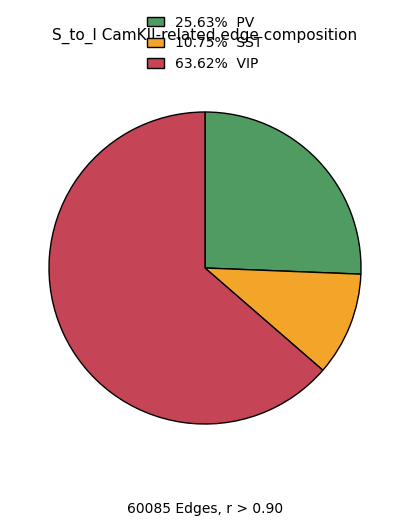

[preview] lonely nodes = 740 (singleton CC nodes: 617, CamKII without PV/SST/VIP links: 638)
[preview] dominant-partner coloring prepared for 1516 CamkII_TST nodes (ties=52, no PV/SST/VIP partners=638).


In [ ]:
import traceback

print(f"[run] event types = {EVENT_TYPES}")
print(f"[run] threshold method = r_threshold")
print(f"[run] threshold list = {R_THRESHOLDs}")

all_threshold_qc_rows = []
all_error_rows = []

for EVENT_TYPE in EVENT_TYPES:
    INPUT_FILE_PATH = os.path.join(PROJECT_PATH, "correlation_analysis", TEST, f"{EVENT_TYPE}_correlation_matrix.csv")
    print("=" * 100)
    print(f"[run] starting event analysis for: {EVENT_TYPE}")
    print(f"[run] input file = {INPUT_FILE_PATH}")

    try:
        data, cell_ids, celltype_info = load_and_validate_data(INPUT_FILE_PATH, TEST, verbose=VERBOSE)
    except Exception as e:
        print(f"[error] failed to load data for event={EVENT_TYPE}")
        print(f"[error] input file: {INPUT_FILE_PATH}")
        print(f"[error] {type(e).__name__}: {e}")
        traceback.print_exc()

        all_error_rows.append({
            "event_type": EVENT_TYPE,
            "r_threshold": np.nan,
            "stage": "load_and_validate_data",
            "input_file": INPUT_FILE_PATH,
            "error_type": type(e).__name__,
            "error_message": str(e),
        })
        continue

    for threshold_value in R_THRESHOLDs:
        R_THRESHOLD = float(threshold_value)
        OUTPUT_DIR = os.path.join(
            PROJECT_PATH,
            "correlation_analysis",
            TEST,
            "R-Thresholds",
            f"{R_THRESHOLD:.2f}",
        )

        try:
            Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

            print("=" * 80)
            print(f"[run] event = {EVENT_TYPE}, threshold = r > {R_THRESHOLD:.2f}")
            print(f"[run] output dir = {OUTPUT_DIR}")

            edge_table, mask_2d, qc_summary = collect_edges_by_r_threshold(
                data_df=data,
                threshold=R_THRESHOLD,
                verbose=VERBOSE,
            )

            adjacency_matrix = binarize_matrix_from_mask(mask_2d, verbose=VERBOSE)
            weight_matrix = get_weight_matrix(data.to_numpy(), mask_2d)
            G, node_df, network_df = analyze_network(weight_matrix, cell_ids, verbose=VERBOSE)

            if celltype_info is None:
                edge_table["source_celltype"] = np.nan
                edge_table["target_celltype"] = np.nan
                excluded_reason_df = pd.DataFrame(
                    [{"reason": "celltype column missing in input CSV", "count": len(edge_table)}]
                )
                camkii_edge_summary_df = pd.DataFrame()
            else:
                celltype_array = celltype_info.to_numpy()
                if len(celltype_array) != len(node_df):
                    raise ValueError(
                        f"celltype length ({len(celltype_array)}) does not match node_df length ({len(node_df)})."
                    )
                node_df["celltype"] = celltype_array
                edge_table["source_celltype"] = celltype_array[edge_table["source_index"].to_numpy()]
                edge_table["target_celltype"] = celltype_array[edge_table["target_index"].to_numpy()]
                excluded_reason_df = pd.DataFrame(
                    [
                        {"reason": "failed r threshold (r <= threshold)", "count": int((~edge_table["selected_by_r_threshold"]).sum())},
                        {"reason": "survived r threshold", "count": int(edge_table["selected_by_r_threshold"].sum())},
                    ]
                )
                camkii_edge_summary_df = summarize_camkii_edges(
                    adjacency_matrix=adjacency_matrix,
                    cell_types=celltype_array,
                    celltype_name_map=CELLTYPE_NAME_MAP,
                    event_type=EVENT_TYPE,
                    threshold_value=R_THRESHOLD,
                )

            edge_table.to_csv(os.path.join(OUTPUT_DIR, f"{EVENT_TYPE}_edge_level_r_threshold_results.csv"), index=False, encoding="utf-8-sig")
            qc_summary.to_csv(os.path.join(OUTPUT_DIR, f"{EVENT_TYPE}_qc_summary.csv"), index=False, encoding="utf-8-sig")
            pd.DataFrame(adjacency_matrix, index=cell_ids, columns=cell_ids).to_csv(
                os.path.join(OUTPUT_DIR, f"{EVENT_TYPE}_adjacency_matrix_r_threshold.csv"),
                encoding="utf-8-sig",
            )
            pd.DataFrame(weight_matrix, index=cell_ids, columns=cell_ids).to_csv(
                os.path.join(OUTPUT_DIR, f"{EVENT_TYPE}_weight_matrix_r_threshold.csv"),
                encoding="utf-8-sig",
            )

            if not camkii_edge_summary_df.empty:
                camkii_edge_summary_df.to_csv(
                    os.path.join(OUTPUT_DIR, f"{EVENT_TYPE}_camkii_edge_summary.csv"),
                    index=False,
                    encoding="utf-8-sig",
                )
                camkii_edge_summary_df.to_csv(
                    os.path.join(OUTPUT_DIR, f"{EVENT_TYPE}_CamkII_edge_counts.csv"),
                    index=False,
                    encoding="utf-8-sig",
                )
                plot_camkii_edge_pie(camkii_edge_summary_df, OUTPUT_DIR, EVENT_TYPE, R_THRESHOLD)
                plot_camkii_dominant_partner_network(
                    weight_matrix=weight_matrix,
                    adjacency_matrix=adjacency_matrix,
                    node_df=node_df,
                    output_dir=OUTPUT_DIR,
                    event_type=EVENT_TYPE,
                    threshold_value=R_THRESHOLD,
                )
            else:
                print("[fallback] skipped CamKII edge summary because celltype annotations are unavailable.")

            qc_row = qc_summary.iloc[0].to_dict()
            qc_row["event_type"] = EVENT_TYPE
            qc_row["output_dir"] = OUTPUT_DIR
            all_threshold_qc_rows.append(qc_row)

        except Exception as e:
            print(f"[error] failed at event={EVENT_TYPE}, r_threshold={R_THRESHOLD:.2f}")
            print(f"[error] output dir: {OUTPUT_DIR}")
            print(f"[error] {type(e).__name__}: {e}")
            traceback.print_exc()

            all_error_rows.append({
                "event_type": EVENT_TYPE,
                "r_threshold": R_THRESHOLD,
                "stage": "threshold_analysis",
                "input_file": INPUT_FILE_PATH,
                "output_dir": OUTPUT_DIR,
                "error_type": type(e).__name__,
                "error_message": str(e),
            })
            continue

all_threshold_qc_df = pd.DataFrame(all_threshold_qc_rows)
all_error_df = pd.DataFrame(all_error_rows)

print("[run] completed all event and threshold analyses")
display(all_threshold_qc_df)

if not all_error_df.empty:
    error_output_path = os.path.join(PROJECT_PATH, "correlation_analysis", TEST, "R-Thresholds", "error_log.csv")
    all_error_df.to_csv(error_output_path, index=False, encoding="utf-8-sig")
    print(f"[run] saved error log to: {error_output_path}")
    display(all_error_df)

In [ ]:
camkii_edge_summary_df

,event_type,source_celltype,target_celltype,significant_edge_count,edge_fraction,edge_percent,total_camkii_related_edges,threshold_method,threshold_value
0,I_to_S,CamkII_TST,PV,7639,0.227074,22.707411,33641,r_threshold,0.9
1,I_to_S,CamkII_TST,SST,3354,0.099700,9.969977,33641,r_threshold,0.9
2,I_to_S,CamkII_TST,VIP,22648,0.673226,67.322612,33641,r_threshold,0.9


In [ ]:
print("[run] all threshold analyses are completed in Cell 6.")
display(all_threshold_qc_df)


[run] all threshold analyses are completed in Cell 6.


,n_nodes,n_candidate_edges,n_selected_edges,fraction_selected_edges,threshold_method,threshold_value,event_type,output_dir
0,2359,2781261,671748,0.241526,r_threshold,0.50,S_to_I,G:\XJN_M2project\correlation_analysis\allcellt...
1,2359,2781261,601817,0.216383,r_threshold,0.55,S_to_I,G:\XJN_M2project\correlation_analysis\allcellt...
2,2359,2781261,533158,0.191697,r_threshold,0.60,S_to_I,G:\XJN_M2project\correlation_analysis\allcellt...
3,2359,2781261,465335,0.167311,r_threshold,0.65,S_to_I,G:\XJN_M2project\correlation_analysis\allcellt...
4,2359,2781261,397761,0.143015,r_threshold,0.70,S_to_I,G:\XJN_M2project\correlation_analysis\allcellt...
5,2359,2781261,330143,0.118703,r_threshold,0.75,S_to_I,G:\XJN_M2project\correlation_analysis\allcellt...
6,2359,2781261,262359,0.094331,r_threshold,0.80,S_to_I,G:\XJN_M2project\correlation_analysis\allcellt...
7,2359,2781261,193103,0.069430,r_threshold,0.85,S_to_I,G:\XJN_M2project\correlation_analysis\allcellt...
8,2359,2781261,124043,0.044600,r_threshold,0.90,S_to_I,G:\XJN_M2project\correlation_analysis\allcellt...
9,2359,2781261,583598,0.209832,r_threshold,0.50,I_to_S,G:\XJN_M2project\correlation_analysis\allcellt...


## Preview

Quick manual QC preview for the thresholded network:

- adjacency matrix after thresholding
- network preview with custom lonely-node definition
- sample edge table rows


In [ ]:
edge_table

,source_index,target_index,source_cell_id,target_cell_id,r_value,selected_by_r_threshold,source_celltype,target_celltype
0,0,1,52,178,0.968415,True,1,1
1,0,2,52,15,-0.458217,False,1,1
2,0,3,52,63,-0.454859,False,1,1
3,0,4,52,64,-0.617320,False,1,1
4,0,5,52,65,-0.534759,False,1,1
...,...,...,...,...,...,...,...,...
2781256,2355,2357,18,6.28,0.874782,False,4,4
2781257,2355,2358,18,7.28,0.874782,False,4,4
2781258,2356,2357,52,6.28,0.959886,True,4,4
2781259,2356,2358,52,7.28,0.959886,True,4,4


In [ ]:
# print("[preview] preparing quick QC plots for the last threshold in R_THRESHOLDs")

# fig, axes = plt.subplots(1, 1, figsize=(6, 4))
# axes.hist(edge_table["r_value"], bins=50, color="#7AA6C2", edgecolor="black")
# axes.axvline(R_THRESHOLD, color="red", linestyle="--", linewidth=1)
# axes.set_title("Edge r-value distribution")
# axes.set_xlabel("r_value")
# axes.set_ylabel("Count")
# plt.tight_layout()
# plt.show()

# if SHOW_VISUALIZATION:
#     plt.figure(figsize=(6, 5))
#     plt.imshow(adjacency_matrix, cmap="gray_r", aspect="auto")
#     plt.colorbar(label="Selected edge (1=yes)")
#     plt.title(f"{EVENT_TYPE} adjacency with r > {R_THRESHOLD:.2f}")
#     plt.xlabel("Cell index")
#     plt.ylabel("Cell index")
#     plt.tight_layout()
#     plt.show()

#     preview_graph = nx.from_numpy_array(weight_matrix, create_using=nx.Graph())
#     preview_forest = minimum_spanning_forest_weighted(preview_graph)
#     preview_pos = build_network_layout(preview_forest)

#     preview_components = list(nx.connected_components(preview_graph))
#     singleton_nodes = set(node for comp in preview_components if len(comp) == 1 for node in comp)

#     if "celltype" in node_df.columns and not node_df["celltype"].isna().all():
#         celltype_lookup = node_df.set_index("Node_Index")["celltype"].to_dict()
#         partner_nodes = [node for node, celltype in celltype_lookup.items() if int(celltype) in {2, 3, 4}]
#         camkii_without_partner_nodes = {
#             node for node, celltype in celltype_lookup.items()
#             if int(celltype) == 1
#             and (len(partner_nodes) == 0 or np.sum(adjacency_matrix[node, partner_nodes]) == 0)
#         }
#     else:
#         celltype_lookup = {}
#         camkii_without_partner_nodes = set()

#     lonely_node_ids = singleton_nodes | camkii_without_partner_nodes
#     print(
#         f"[preview] lonely nodes = {len(lonely_node_ids)} "
#         f"(singleton CC nodes: {len(singleton_nodes)}, "
#         f"CamKII without PV/SST/VIP links: {len(camkii_without_partner_nodes)})"
#     )

#     preview_degrees = dict(preview_forest.degree())
#     multi_degs = [deg for node, deg in preview_degrees.items() if node not in lonely_node_ids]
#     min_size, max_size, fixed_single_size = 30, 250, 20
#     if multi_degs:
#         min_d, max_d = min(multi_degs), max(multi_degs)
#         node_sizes = [
#             fixed_single_size
#             if node in lonely_node_ids
#             else min_size + (max_size - min_size) * (deg - min_d) / (max_d - min_d + 1e-8)
#             for node, deg in preview_degrees.items()
#         ]
#     else:
#         node_sizes = [fixed_single_size] * len(preview_degrees)

#     node_alphas = [0.1 if n in lonely_node_ids else 0.8 for n in preview_forest.nodes()]
#     if celltype_lookup:
#         node_colors = [
#             CELLTYPE_COLOR_MAP.get(int(celltype_lookup[node]), "#000DFF")
#             if node not in lonely_node_ids
#             else "#D9D9D9"
#             for node in preview_forest.nodes()
#         ]
#     else:
#         node_colors = ["#9E9E9E" if node in lonely_node_ids else "#4C78A8" for node in preview_forest.nodes()]

#     edges = preview_forest.edges(data=True)
#     edge_weights = [data["weight"] for _, _, data in preview_forest.edges(data=True)]
#     if edge_weights:
#         min_w = min(edge_weights)
#         max_w = max(edge_weights)
#         edge_alphas = []
#         for u, v, corr_val in edges:
#             if (u in lonely_node_ids) or (v in lonely_node_ids):
#                 alpha = 0.1
#             elif max_w > min_w:
#                 normalized = (corr_val["weight"] - min_w) / (max_w - min_w)
#                 alpha = 0.2 + 0.7 * normalized
#             else:
#                 alpha = 0.8
#             edge_alphas.append(alpha)
#     else:
#         edge_alphas = []

#     fig, ax = plt.subplots(figsize=(10, 8))
#     nx.draw_networkx_nodes(
#         preview_forest,
#         preview_pos,
#         ax=ax,
#         node_size=node_sizes,
#         node_color=node_colors,
#         edgecolors="none",
#         linewidths=0.3,
#         alpha=node_alphas,
#     )
#     nx.draw_networkx_edges(preview_forest, preview_pos, ax=ax, edge_color="black", alpha=edge_alphas)

#     legend_elements = [
#         plt.Line2D([0], [0], marker="o", color="w", label=name, markerfacecolor=color, markeredgecolor="black", markersize=9)
#         for key, name in CELLTYPE_NAME_MAP.items()
#         for color in [CELLTYPE_COLOR_MAP.get(key, "#BFBFBF")]
#     ]
#     ax.legend(handles=legend_elements, loc="upper right", fontsize=8)
#     ax.set_title(f"{EVENT_TYPE} network preview after r-threshold selection")
#     ax.axis("off")
#     plt.tight_layout()
#     plt.show()

# print("[preview] sample rows from edge table for the last threshold")
# display(edge_table.head())


## Supplemental Robustness Analysis: Node-Weighted CaMKII Edge Count

This section keeps the **current r-thresholded network** unchanged and adds a supplemental uncertainty analysis for CaMKII-centered edge count.

- Bootstrap unit: valid CaMKII node
- Statistic type: **node-weighted edge count**, not edge-weighted proportion
- Exclusion rule: CaMKII nodes with `k_total == 0` are excluded from node-weighted edge-count estimation but retained in QC accounting


In [ ]:
# print("[supplemental] node-weighted edge count analysis has already been run for every threshold in Cell 6.")
# print("[supplemental] displaying the last threshold result held in memory.")
# display(camkii_node_weighted_node_level_df.head())
# display(camkii_node_weighted_summary_df)


## Cross-Threshold CaMKII Edge Summary Curves

This section reads the saved `camkii_edge_summary.csv` files under each threshold directory and summarizes how CaMKII-related edge percent changes with `r`.

- one line plot for `PV-CaMKII`
- one line plot for `SST-CaMKII`
- one line plot for `VIP-CaMKII`
- each plot overlays both `S_to_I` and `I_to_S`


In [ ]:
def load_camkii_edge_summary_across_thresholds(project_path, test, event_types, r_thresholds):
    summary_frames = []
    missing_paths = []

    for event_type in event_types:
        for threshold_value in r_thresholds:
            threshold_value = float(threshold_value)
            threshold_dir = os.path.join(
                project_path,
                "correlation_analysis",
                test,
                "R-Thresholds",
                f"{threshold_value:.2f}",
            )
            summary_path = os.path.join(threshold_dir, f"{event_type}_camkii_edge_summary.csv")

            if not os.path.exists(summary_path):
                missing_paths.append(summary_path)
                continue

            summary_df = pd.read_csv(summary_path)
            if summary_df.empty:
                print(f"[fallback] empty summary file skipped: {summary_path}")
                continue

            summary_df["event_type"] = event_type
            summary_df["r_threshold"] = threshold_value
            summary_df["summary_path"] = summary_path
            summary_frames.append(summary_df)

    if missing_paths:
        print("[fallback] missing summary files:")
        for path in missing_paths:
            print(f"  - {path}")

    if not summary_frames:
        return pd.DataFrame()

    combined_summary_df = pd.concat(summary_frames, axis=0, ignore_index=True)
    combined_summary_df = combined_summary_df.sort_values(["target_celltype", "event_type", "r_threshold"]).reset_index(drop=True)
    return combined_summary_df


def plot_camkii_edge_percent_curve_by_subtype(summary_df, target_subtype, output_dir):
    subtype_df = summary_df.loc[summary_df["target_celltype"] == target_subtype].copy()
    subtype_df = subtype_df.sort_values(["event_type", "r_threshold"]).reset_index(drop=True)

    if subtype_df.empty:
        print(f"[fallback] no summary rows found for subtype: {target_subtype}")
        return

    fig, ax = plt.subplots(figsize=(6.8, 4.8))
    for event_type in EVENT_TYPES:
        event_df = subtype_df.loc[subtype_df["event_type"] == event_type].copy()
        if event_df.empty:
            print(f"[fallback] no rows found for event {event_type} and subtype {target_subtype}")
            continue

        ax.plot(
            event_df["r_threshold"],
            event_df["edge_percent"],
            marker="o",
            linewidth=2,
            markersize=6,
            color=EVENT_CURVE_COLOR_MAP.get(event_type, "#4C78A8"),
            label=event_type,
        )

    title_text = f"{target_subtype}-CaMKII edge percent across r thresholds"
    comparison_df = subtype_df.pivot_table(
        index="r_threshold",
        columns="event_type",
        values="edge_percent",
        aggfunc="first",
    )
    if {"S_to_I", "I_to_S"}.issubset(comparison_df.columns):
        paired_df = comparison_df.loc[:, ["S_to_I", "I_to_S"]].dropna().sort_index()
        if paired_df.empty:
            print(f"[fallback] no paired S_to_I/I_to_S thresholds found for subtype: {target_subtype}")
        else:
            delta_percent = paired_df["S_to_I"] - paired_df["I_to_S"]
            delta_min = delta_percent.min()
            delta_max = delta_percent.max()
            if len(paired_df) >= 2:
                auc_delta = np.trapz(paired_df["S_to_I"], paired_df.index) - np.trapz(paired_df["I_to_S"], paired_df.index)
                auc_text = f"Delta AUC={auc_delta:.2f}"
            else:
                print(f"[fallback] fewer than two paired thresholds for subtype: {target_subtype}; AUC set to NA")
                auc_text = "Delta AUC=NA"
            title_text += f"\nDelta(S_to_I-I_to_S) range={delta_min:.2f} to {delta_max:.2f} pp; {auc_text}"
    else:
        print(f"[fallback] S_to_I and I_to_S are not both available for subtype: {target_subtype}")

    ax.set_xlabel("r threshold")
    ax.set_ylabel("CaMKII-related edge percent")
    ax.set_title(title_text)
    ax.grid(alpha=0.3)
    ax.legend(frameon=False)

    plt.tight_layout()
    png_path = os.path.join(output_dir, f"{target_subtype}_CamKII_edge_percent_curve.png")
    pdf_path = os.path.join(output_dir, f"{target_subtype}_CamKII_edge_percent_curve.pdf")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    print(f"[curve] saved {target_subtype} edge-percent curve to: {png_path}")
    print(f"[curve] saved {target_subtype} edge-percent curve to: {pdf_path}")
    plt.show()


[summary] loading saved camkii_edge_summary.csv files across thresholds and events
[summary] saved combined threshold summary to: G:\XJN_M2project\correlation_analysis\allcelltypes\R-Thresholds\summary_curves\camkii_edge_summary_across_thresholds_all_events.csv


C:\Users\Tony.S\AppData\Local\Temp\ipykernel_24696\3312897504.py:85: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_delta = np.trapz(paired_df["S_to_I"], paired_df.index) - np.trapz(paired_df["I_to_S"], paired_df.index)


[curve] saved PV edge-percent curve to: G:\XJN_M2project\correlation_analysis\allcelltypes\R-Thresholds\summary_curves\PV_CamKII_edge_percent_curve.png
[curve] saved PV edge-percent curve to: G:\XJN_M2project\correlation_analysis\allcelltypes\R-Thresholds\summary_curves\PV_CamKII_edge_percent_curve.pdf


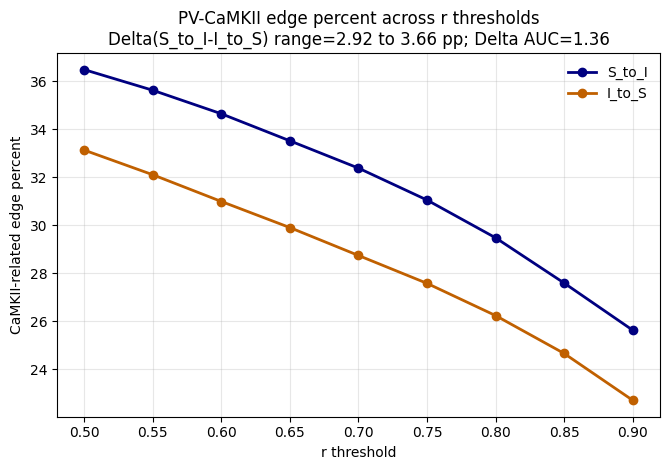

C:\Users\Tony.S\AppData\Local\Temp\ipykernel_24696\3312897504.py:85: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_delta = np.trapz(paired_df["S_to_I"], paired_df.index) - np.trapz(paired_df["I_to_S"], paired_df.index)


[curve] saved SST edge-percent curve to: G:\XJN_M2project\correlation_analysis\allcelltypes\R-Thresholds\summary_curves\SST_CamKII_edge_percent_curve.png
[curve] saved SST edge-percent curve to: G:\XJN_M2project\correlation_analysis\allcelltypes\R-Thresholds\summary_curves\SST_CamKII_edge_percent_curve.pdf


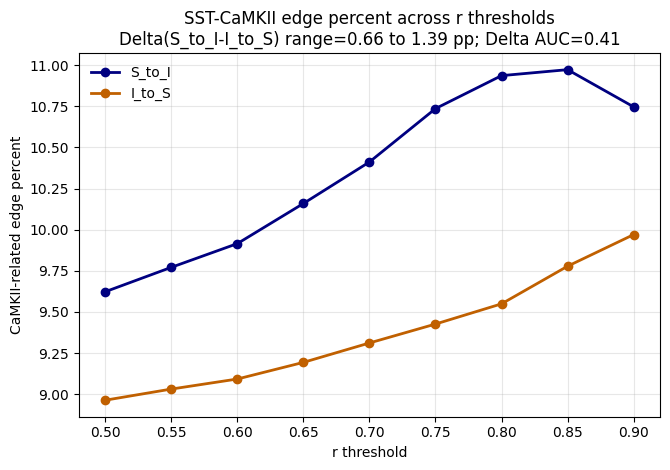

C:\Users\Tony.S\AppData\Local\Temp\ipykernel_24696\3312897504.py:85: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_delta = np.trapz(paired_df["S_to_I"], paired_df.index) - np.trapz(paired_df["I_to_S"], paired_df.index)


[curve] saved VIP edge-percent curve to: G:\XJN_M2project\correlation_analysis\allcelltypes\R-Thresholds\summary_curves\VIP_CamKII_edge_percent_curve.png
[curve] saved VIP edge-percent curve to: G:\XJN_M2project\correlation_analysis\allcelltypes\R-Thresholds\summary_curves\VIP_CamKII_edge_percent_curve.pdf


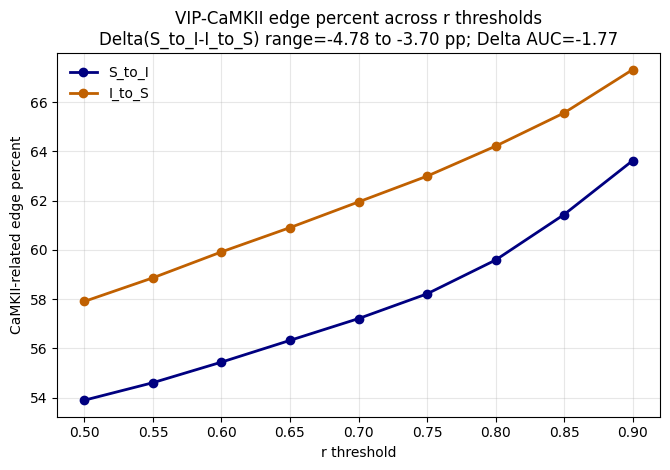

,event_type,source_celltype,target_celltype,significant_edge_count,edge_fraction,edge_percent,total_camkii_related_edges,threshold_method,threshold_value,r_threshold,summary_path
0,I_to_S,CamkII_TST,PV,89043,0.331293,33.129321,268774,r_threshold,0.50,0.50,G:\XJN_M2project\correlation_analysis\allcellt...
1,I_to_S,CamkII_TST,PV,76214,0.321027,32.102676,237407,r_threshold,0.55,0.55,G:\XJN_M2project\correlation_analysis\allcellt...
2,I_to_S,CamkII_TST,PV,64106,0.309890,30.988993,206867,r_threshold,0.60,0.60,G:\XJN_M2project\correlation_analysis\allcellt...
3,I_to_S,CamkII_TST,PV,52749,0.299012,29.901197,176411,r_threshold,0.65,0.65,G:\XJN_M2project\correlation_analysis\allcellt...
4,I_to_S,CamkII_TST,PV,42160,0.287395,28.739511,146697,r_threshold,0.70,0.70,G:\XJN_M2project\correlation_analysis\allcellt...
5,I_to_S,CamkII_TST,PV,32339,0.275782,27.578179,117263,r_threshold,0.75,0.75,G:\XJN_M2project\correlation_analysis\allcellt...
6,I_to_S,CamkII_TST,PV,23122,0.262359,26.235944,88131,r_threshold,0.80,0.80,G:\XJN_M2project\correlation_analysis\allcellt...
7,I_to_S,CamkII_TST,PV,14828,0.246579,24.657853,60135,r_threshold,0.85,0.85,G:\XJN_M2project\correlation_analysis\allcellt...
8,I_to_S,CamkII_TST,PV,7639,0.227074,22.707411,33641,r_threshold,0.90,0.90,G:\XJN_M2project\correlation_analysis\allcellt...
9,S_to_I,CamkII_TST,PV,116809,0.364842,36.484228,320163,r_threshold,0.50,0.50,G:\XJN_M2project\correlation_analysis\allcellt...


In [ ]:
print("[summary] loading saved camkii_edge_summary.csv files across thresholds and events")

curve_output_dir = os.path.join(PROJECT_PATH, "correlation_analysis", TEST, "R-Thresholds", "summary_curves")
Path(curve_output_dir).mkdir(parents=True, exist_ok=True)

camkii_edge_summary_across_thresholds_df = load_camkii_edge_summary_across_thresholds(
    project_path=PROJECT_PATH,
    test=TEST,
    event_types=EVENT_TYPES,
    r_thresholds=R_THRESHOLDs,
)

if camkii_edge_summary_across_thresholds_df.empty:
    print("[fallback] no cross-threshold CaMKII edge summary data found.")
else:
    combined_summary_output_path = os.path.join(
        curve_output_dir,
        "camkii_edge_summary_across_thresholds_all_events.csv",
    )
    camkii_edge_summary_across_thresholds_df.to_csv(
        combined_summary_output_path,
        index=False,
        encoding="utf-8-sig",
    )
    print(f"[summary] saved combined threshold summary to: {combined_summary_output_path}")

    for target_subtype in ["PV", "SST", "VIP"]:
        plot_camkii_edge_percent_curve_by_subtype(
            summary_df=camkii_edge_summary_across_thresholds_df,
            target_subtype=target_subtype,
            output_dir=curve_output_dir,
        )

    display(camkii_edge_summary_across_thresholds_df)
